# Extract data from Polymarket and Kalshi

## Goal

A hands-on Python tutorial: discover a market, fetch its book and trades, download price history,
explore analytics, and save the results. **This notebook is standalone:** it uses ordinary HTTP
requests and does not import any project files or either platform's SDK.

**Start here:** run the cells in order. The main REST examples need internet access but no account
or API key. The later streaming and private-account examples are optional switches. All examples
read data; none place orders. Basic Python knowledge is enough. Python 3.11+ is recommended.

API documentation checked **7 September 2026**. Saved outputs are examples from the validation run;
rerunning fetches fresh data, so markets, timestamps, and row counts will change.

| API surface | What we extract | Access in this tutorial |
|---|---|---|
| Polymarket **Gamma** | Events, markets, tags, search, descriptions, comments | Public REST |
| Polymarket **CLOB** | Books, buy/sell quotes, midpoint, spread, trading parameters, sampled price history | Public REST, including a batch read |
| Polymarket **Data API** | Trades, holders, open interest, wallet positions/activity/value, leaderboard | Public REST |
| Polymarket **market WebSocket / RTDS** | Live prediction-market messages / underlying crypto prices | Optional public streams |
| Kalshi **Trade API** | Series, events, markets, books, trades, OHLC candles, reference data | Public REST |
| Kalshi **historical API** | Archive cutoffs, older markets, trades, candles | Public REST |
| Both platforms' **account APIs** | Your orders, positions, fills, or balance | Optional; existing credentials required |
| Kalshi **WebSocket** | Ticker, trade, and book updates | Optional; authenticated connection |

The short examples cover many data types without trying to enumerate every endpoint.
Additional API families and official references are linked at the end.

## Setup

Install into the **current notebook kernel**. JupyterLab, VS Code, or Google Colab can open this
file. If installing changes an already-imported package, restart the kernel and run again.
`cryptography` and `websockets` are used only in the optional sections.

In [1]:
%pip -q install "requests>=2.32,<3" "pandas>=2.2,<4" "matplotlib>=3.9,<4" "cryptography>=44" "websockets>=15,<17"

Note: you may need to restart the kernel to use updated packages.


### Settings and a small HTTP helper

`get_json(BASE, "/path", parameter=value)` is the pattern used throughout. It checks HTTP errors,
uses a timeout, and retries a few temporary failures. Requests and their public JSON responses
stay in memory for the export example. Failed calls stop the cell instead of masquerading as
empty datasets. Private calls later use separate helpers and are excluded from this log.

In [2]:
import asyncio
import base64
import hashlib
import hmac
import json
import os
import time
from datetime import datetime, timezone
from decimal import Decimal
from pathlib import Path
from urllib.parse import quote, urlsplit

import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import display
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

GAMMA = "https://gamma-api.polymarket.com"
CLOB = "https://clob.polymarket.com"
DATA = "https://data-api.polymarket.com"
KALSHI = "https://external-api.kalshi.com/trade-api/v2"

SEARCH_TEXT = "Fed"           # Search preview only; later examples use the selected sample markets.
HISTORY_DAYS = 7
RUN_STREAMS = False           # Bounded captures; about 8 seconds each at most.
RUN_POLY_PRIVATE = False      # Load your existing credentials only when True.
RUN_KALSHI_PRIVATE = False
EXPORT_FILES = False          # Turn on to write JSON/CSV into a new local folder.

RUN_AT = datetime.now(timezone.utc)
END_TS = int(RUN_AT.timestamp())
START_TS = END_TS - HISTORY_DAYS * 24 * 60 * 60
public_responses = []

session = requests.Session()
session.headers.update({"User-Agent": "prediction-api-tutorial/1.0"})
retry = Retry(total=2, backoff_factor=0.5, status_forcelist=[429, 500, 502, 503, 504],
              allowed_methods={"GET"})
session.mount("https://", HTTPAdapter(max_retries=retry))

def fetch_json(base, path, *, method="GET", params=None, body=None):
    response = session.request(method, base + path, params=params, json=body, timeout=(10, 30))
    response.raise_for_status()
    payload = response.json()
    public_responses.append({
        "retrieved_at_utc": datetime.now(timezone.utc).isoformat(),
        "method": method, "url": response.url, "request_body": body, "data": payload,
    })
    return payload

def get_json(base, path, **params):
    return fetch_json(base, path, params=params)

def preview(rows, columns=None, n=5):
    frame = pd.json_normalize(rows)
    if columns is not None:
        frame = frame.reindex(columns=columns)
    display(frame.head(n))
    return frame

def json_list(value):
    # Gamma sometimes returns arrays as JSON-encoded strings.
    return json.loads(value) if isinstance(value, str) else (value or [])

print("Run started (UTC):", RUN_AT.isoformat())

Run started (UTC): 2026-09-06T18:01:31.167620+00:00


## Steps

### 1. Understand the identifiers

Polymarket: **event → market → outcome tokens**. An event may contain many markets. Each market
has a Gamma ID, a condition ID, and separate tradable tokens for its outcomes.

Kalshi: **series → event → market**. A series is a recurring template; an event is one occurrence;
a market is a specific binary contract within it.

| Identifier | Where it comes from | Where to use it |
|---|---|---|
| Polymarket event `id` | Gamma event | Event detail, comments, event volume |
| Polymarket market `id` | Gamma market | Gamma market detail |
| Polymarket `conditionId` | Gamma market | Data API market filters, CLOB condition metadata |
| Polymarket outcome token ID | Gamma `clobTokenIds`, paired with `outcomes` | CLOB books, prices, history, market WebSocket |
| Kalshi `series_ticker` | Series catalog / event detail | Series detail, live candle route |
| Kalshi `event_ticker` | Event / market | Event detail |
| Kalshi market `ticker` | Market | Book, trades, candles |

Keep IDs as **strings**, especially Polymarket's long token IDs. Pair outcomes and tokens by
position; do not assume that the first outcome is named Yes.
Sources: [Polymarket markets and events](https://docs.polymarket.com/concepts/markets-events),
[Kalshi market-data quickstart](https://docs.kalshi.com/getting_started/quick_start_market_data).

### 2. Polymarket Gamma: discover active events and markets

The classic `/events` endpoint supports a small, sorted discovery sample. Its nested `markets`
provide the IDs needed by other APIs. We select an accepting-orders market from these results,
preferring a binary market whose displayed prices are away from 0 and 1, then recent volume.
This selection is just to make the tutorial's book and history interesting.
[Discovery docs](https://docs.polymarket.com/market-data/discover-markets).

In [3]:
poly_events = get_json(GAMMA, "/events", closed="false", active="true",
                       order="volume24hr", ascending="false", limit=10)
poly_events_df = preview(poly_events, ["id", "title", "slug", "volume24hr", "liquidity"])

candidates = [
    (event, market)
    for event in poly_events
    for market in event.get("markets", [])
    if market.get("acceptingOrders") and market.get("enableOrderBook")
    and market.get("conditionId") and json_list(market.get("clobTokenIds"))
]
if not candidates:
    raise ValueError("No tradable markets in this sample. Increase limit or change discovery filters.")

def sample_score(pair):
    market = pair[1]
    prices = [float(p) for p in json_list(market.get("outcomePrices"))]
    balanced = len(prices) == 2 and all(0.10 < p < 0.90 for p in prices)
    return balanced, float(market.get("volume24hr") or 0)

poly_event, poly_market = max(candidates, key=sample_score)
outcomes = json_list(poly_market["outcomes"])
token_ids = [str(t) for t in json_list(poly_market["clobTokenIds"])]
assert len(outcomes) == len(token_ids), "Outcome/token mapping changed; inspect the raw market."
token_by_outcome = dict(zip(outcomes, token_ids))
poly_outcome = "Yes" if "Yes" in token_by_outcome else outcomes[0]
token_id = token_by_outcome[poly_outcome]
condition_id = poly_market["conditionId"]
print(poly_market["question"])
display(pd.DataFrame({"outcome": outcomes, "token_id": token_ids}))

,id,title,slug,volume24hr,liquidity
0,899514,Everton FC vs. Manchester United FC,epl-eve-mun-2026-09-06,9.436657e+06,9.303209e+05
1,971101,Counter-Strike: Spirit vs MOUZ (BO5) - BLAST O...,cs2-ts7-mouz-2026-09-06,8.117879e+06,5.637094e+05
2,970923,LoL: G2 Esports vs Karmine Corp (BO5) - LEC Pl...,lol-g2-kc-2026-09-06,3.376354e+06,2.853629e+06
3,481717,Fed Decision in September?,fed-decision-in-september-762,1.837524e+06,6.819085e+06
4,79987,Next French Presidential Election,next-french-presidential-election,9.564484e+05,1.617675e+07


LoL: G2 Esports vs Karmine Corp (BO5) - LEC Playoffs


,outcome,token_id
0,G2 Esports,1684145989073711738663912742269684878119845785...
1,Karmine Corp,4186485942066548595801785471948020389999550862...


### 3. Gamma: keyword search, tags, and resolution text

Search returns an object containing events (and optionally tags/profiles), rather than a plain
market list. Search pagination uses `page`; the returned `pagination.hasMore` indicates another
page. Tags give another way to filter discovery. Read the full description before comparing
contracts across platforms; similar titles can hide different settlement conditions.
[Market detail docs](https://docs.polymarket.com/market-data/market-details).

In [4]:
poly_search = get_json(GAMMA, "/public-search", q=SEARCH_TEXT,
                       limit_per_type=5, page=1, search_profiles="false")
_ = preview(poly_search.get("events", []), ["id", "title", "slug"])
print("Search pagination:", poly_search.get("pagination"))

poly_tags = get_json(GAMMA, "/tags", limit=5, offset=0)
_ = preview(poly_tags, ["id", "label", "slug"])

poly_detail = get_json(GAMMA, f"/markets/{poly_market['id']}")
print("Description excerpt:", (poly_detail.get("description") or "(not supplied)")[:700])
# Example tag filter: get_json(GAMMA, "/events", tag_id=poly_tags[0]["id"], closed="false", limit=5)

,id,title,slug
0,481717,Fed Decision in September?,fed-decision-in-september-762
1,51456,How many Fed rate cuts in 2026?,how-many-fed-rate-cuts-in-2026
2,101936,Fed rate hike in 2026?,fed-rate-hike-in-2026
3,606422,Fed Decision in October?,fed-decision-in-october-20260617190323537
4,106884,Fed rate cut by...?,fed-rate-cut-by-629


Search pagination: {'hasMore': True, 'totalResults': 649}


,id,label,slug
0,101867,product marekt fit,product-marekt-fit
1,1512,caitlin clark,caitlin-clark
2,100601,virgins,virgins
3,101025,Viktoria Plzen,viktoria-plzen
4,101457,Jerry After Dark,jerry-after-dark


Description excerpt: This market refers to the LoL Upper bracket final match between G2 Esports and Karmine Corp in the LEC Playoffs, initially scheduled for September 6, 2026 at 11:00 AM ET.

This market will resolve to "G2 Esports" if G2 Esports win the match against Karmine Corp.

This market will resolve to "Karmine Corp" if Karmine Corp win the match against G2 Esports.

If the match is canceled (not played at all) or ends in a tie, this market will resolve to 50-50.

If the match is postponed, it must be rescheduled to a start time on or before September 20, 2026 at 11:59 PM ET (14 calendar days after the originally scheduled start of September 6, 2026 at 11:00 AM ET). If, by that deadline, the most recent


### 4. Gamma: cursor pagination

Current `/markets/keyset` and `/events/keyset` endpoints return `next_cursor`; send it back as
`after_cursor`. Older `/markets` and `/events` lists use `limit`/`offset`. **Do not mix them.**
The loop below intentionally stops after two small pages and retains the continuation cursor.
The result is a sample, not a full catalog. Listings may change while you paginate.
[Gamma API schema](https://docs.polymarket.com/api-spec/gamma-openapi.yaml).

In [5]:
poly_market_rows = []
poly_next_cursor = None
seen_cursors = set()
for page_number in range(2):
    params = {"closed": "false", "limit": 5}
    if poly_next_cursor:
        params["after_cursor"] = poly_next_cursor
    page = get_json(GAMMA, "/markets/keyset", **params)
    poly_market_rows.extend(page["markets"])
    poly_next_cursor = page.get("next_cursor")
    if not poly_next_cursor:
        break
    if poly_next_cursor in seen_cursors:
        raise RuntimeError("Repeated Gamma cursor; inspect the response before continuing.")
    seen_cursors.add(poly_next_cursor)

print("Rows:", len(poly_market_rows), "| More available:", bool(poly_next_cursor))
_ = preview(poly_market_rows, ["id", "question", "conditionId"])

Rows: 10 | More available: True


,id,question,conditionId
0,559651,Xi Jinping out before 2027?,0xa467b14d51f01b957109d9cbb1d6c124fab2a089d52e...
1,559652,Will Gavin Newsom win the 2028 Democratic pres...,0x0f49db97f71c68b1e42a6d16e3de93d85dbf7d4148e3...
2,559653,Will Alexandria Ocasio-Cortez win the 2028 Dem...,0xe6bcc2f1dd025ce5e1833190f7c60a71171c94f805df...
3,559654,Will Pete Buttigieg win the 2028 Democratic pr...,0x4c325469d9b516ef4e6b8f73a81a12607dec075e3c2f...
4,559655,Will Josh Shapiro win the 2028 Democratic pres...,0xd65891729ce093cc12236856837eba1a0872fc7998fd...


### 5. CLOB: fetch and interpret an order book

Use the **outcome token ID**, not the Gamma market ID. A book is a current snapshot of resting
orders. Price is collateral value per outcome share (displayed on a 0–1 scale); size is the
number of outcome shares. Price and size arrive as strings. `Decimal` preserves their decimal values; floats are
fine for plotting later. Sort the arrays explicitly: the best bid is the maximum bid, and the
best ask is the minimum ask. An empty side stays missing.
[Prices and order books](https://docs.polymarket.com/market-data/prices-order-books).

In [6]:
poly_book = get_json(CLOB, "/book", token_id=token_id)
poly_book_df = pd.DataFrame([
    {"side": side, "price": Decimal(level["price"]), "size": Decimal(level["size"])}
    for side in ("bids", "asks") for level in poly_book.get(side, [])
], columns=["side", "price", "size"])
poly_bids = poly_book_df.query("side == 'bids'").sort_values("price", ascending=False)
poly_asks = poly_book_df.query("side == 'asks'").sort_values("price")
poly_best_bid = poly_bids.iloc[0]["price"] if not poly_bids.empty else None
poly_best_ask = poly_asks.iloc[0]["price"] if not poly_asks.empty else None
print("Outcome:", poly_outcome, "| Best bid:", poly_best_bid, "| Best ask:", poly_best_ask)
display(pd.concat([poly_bids.head(5), poly_asks.head(5)], ignore_index=True))

Outcome: G2 Esports | Best bid: 0.71 | Best ask: 0.73


,side,price,size
0,bids,0.71,206.22
1,bids,0.7,33576
2,bids,0.69,311.73
3,bids,0.68,481.2
4,bids,0.67,1090.67
5,asks,0.73,1277.3
6,asks,0.74,1310.61
7,asks,0.75,4164.52
8,asks,0.76,1412.96
9,asks,0.77,259


### 6. CLOB: quotes, trading parameters, and batch books

The [endpoint reference](https://docs.polymarket.com/api-reference/market-data/get-market-price)
defines `/price?side=BUY` as the best **bid**, and `SELL` as the best **ask**, which matched our
live checks. Some higher-level examples use the opposite trading-direction convention, so the
table preserves raw side labels. For an immediate purchase use the **ask** from `/book`; for an
immediate sale use its **bid**. Midpoint, quote, and last trade are different observations, and sequential
requests can disagree when the market moves. `/books` uses a **read-only POST** for batching.
Token metadata also includes tick size, fees, and negative-risk status; keep those raw fields
when studying execution costs. [CLOB API schema](https://docs.polymarket.com/api-spec/clob-openapi.yaml).

In [7]:
poly_quotes = {
    "price_side_BUY": get_json(CLOB, "/price", token_id=token_id, side="BUY"),
    "price_side_SELL": get_json(CLOB, "/price", token_id=token_id, side="SELL"),
    "midpoint": get_json(CLOB, "/midpoint", token_id=token_id),
    "spread": get_json(CLOB, "/spread", token_id=token_id),
    "last_trade": get_json(CLOB, "/last-trade-price", token_id=token_id),
}
display(pd.DataFrame([{"observation": name, "response": value}
                      for name, value in poly_quotes.items()]))

poly_parameters = {
    "tick_size": get_json(CLOB, "/tick-size", token_id=token_id),
    "fee_rate": get_json(CLOB, "/fee-rate", token_id=token_id),
    "negative_risk": get_json(CLOB, "/neg-risk", token_id=token_id),
}
print(poly_parameters)
poly_batch_books = fetch_json(CLOB, "/books", method="POST",
                             body=[{"token_id": token} for token in token_ids[:2]])
print("Batch book count:", len(poly_batch_books))

,observation,response
0,price_side_BUY,{'price': '0.71'}
1,price_side_SELL,{'price': '0.72'}
2,midpoint,{'mid': '0.715'}
3,spread,{'spread': '0.01'}
4,last_trade,"{'price': '0.73', 'side': 'BUY'}"


{'tick_size': {'minimum_tick_size': 0.01}, 'fee_rate': {'base_fee': 1000}, 'negative_risk': {'neg_risk': False}}
Batch book count: 2


### 7. CLOB: sampled price history

`market` here means the **token ID**. `startTs` and `endTs` are Unix **seconds**;
`fidelity` is in **minutes**. Alternatively use `interval="1w"` without a start/end range.
The response contains `history` rows with `t` (timestamp) and `p` (sampled price).
This series is not OHLC candles or a historical order book. An empty history is possible for a
new token or an unavailable time window.
[History reference](https://docs.polymarket.com/api-reference/markets/get-prices-history).

,time_utc,price
0,2026-09-05 19:00:32+00:00,0.515
1,2026-09-05 20:00:17+00:00,0.495
2,2026-09-05 21:00:28+00:00,0.485
3,2026-09-05 22:00:17+00:00,0.475
4,2026-09-05 23:00:17+00:00,0.475


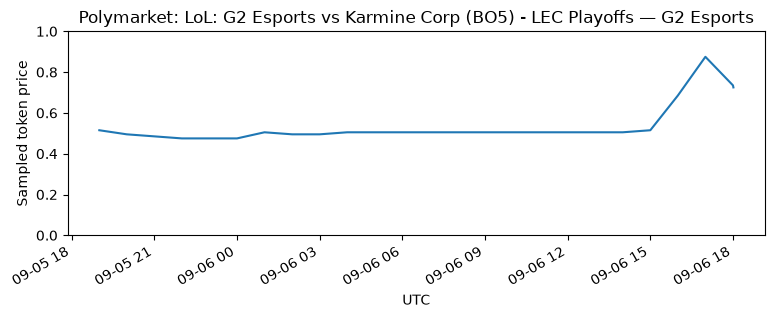

In [8]:
poly_history = get_json(CLOB, "/prices-history", market=token_id,
                        startTs=START_TS, endTs=END_TS, fidelity=60)
poly_history_df = pd.DataFrame(poly_history.get("history", []), columns=["t", "p"])
poly_history_df["time_utc"] = pd.to_datetime(poly_history_df["t"], unit="s", utc=True)
poly_history_df["price"] = pd.to_numeric(poly_history_df["p"], errors="raise")
poly_history_df = poly_history_df.sort_values("time_utc")
display(poly_history_df[["time_utc", "price"]].head())
if not poly_history_df.empty:
    ax = poly_history_df.plot(x="time_utc", y="price", figsize=(9, 3), legend=False,
                              title=f"Polymarket: {poly_market['question']} — {poly_outcome}")
    ax.set(xlabel="UTC", ylabel="Sampled token price", ylim=(0, 1))
    plt.show()
else:
    print("No sampled prices returned for this token/window.")

### 8. Data API: public trades, holders, open interest, and event volume

The market filter now takes a **condition ID**. Trades show executions; holders and open interest
are current snapshots. `/holders` returns top holders per outcome, not a complete shareholder
register. Trade `size` and holder `amount` are outcome-share quantities; trade `price` is per-share
collateral value. Keep endpoint-reported open-interest and volume fields separate from these
share quantities and from Kalshi contract counts. Multiple condition IDs can be comma-separated; `market` and `eventId` filters are
mutually exclusive. Keep `takerOnly=true` to avoid treating both participants as separate volume.
[Public trades reference](https://docs.polymarket.com/api-reference/core/get-trades-for-a-user-or-markets),
[Data API schema](https://docs.polymarket.com/api-spec/data-openapi.yaml).

In [9]:
poly_trades = get_json(DATA, "/trades", market=condition_id, limit=20, offset=0, takerOnly="true")
poly_trades_df = preview(poly_trades, ["timestamp", "outcome", "side", "price", "size", "transactionHash"])
if not poly_trades_df.empty:
    poly_trades_df["time_utc"] = pd.to_datetime(poly_trades_df["timestamp"], unit="s", utc=True)

poly_holders = get_json(DATA, "/holders", market=condition_id, limit=5)
holder_rows = [{"token": group.get("token"), **holder}
               for group in poly_holders for holder in group.get("holders", [])]
_ = preview(holder_rows, ["token", "proxyWallet", "amount", "outcomeIndex"])
poly_open_interest = get_json(DATA, "/oi", market=condition_id)
poly_event_volume = get_json(DATA, "/live-volume", id=poly_event["id"])
print("Open interest:", poly_open_interest)
print("Event volume totals:", [event.get("total") for event in poly_event_volume])

,timestamp,outcome,side,price,size,transactionHash
0,1788717520,G2 Esports,BUY,0.73,20.547944,0x4a1ab1f7e5bec94a29fab9b41ba9a3611b20a2543c54...
1,1788717456,G2 Esports,BUY,0.73,41.095888,0x6f6461c758eba2febda082c19f8e22321c080ba9350c...
2,1788717415,G2 Esports,BUY,0.73,2.739725,0x6390d84239e99c10d4dfae5f787567e35f073d727107...
3,1788717387,G2 Esports,BUY,0.73,2311.287670,0x789158db0aaa8f2f6f60dd204f6bfbc43be9f9da340e...
4,1788717289,G2 Esports,BUY,0.73,12.506848,0x012ac3fc2af831e53920ed4e8e836aa70c2ae896a52d...


,token,proxyWallet,amount,outcomeIndex
0,1684145989073711738663912742269684878119845785...,0x8a8685a792c184e5c2ee8c7d4d4baba7c2c94998,184045.007754,0
1,1684145989073711738663912742269684878119845785...,0x2117ae94a97d69b78cbc81b6680a62deb1955c26,69818.758170,0
2,1684145989073711738663912742269684878119845785...,0x1610db79f753a80207e1d66716be9e91e627ae49,36120.230000,0
3,1684145989073711738663912742269684878119845785...,0x6f3e7f25baa7d2d49e15e2d2957ff3dec62cbcf8,33591.467873,0
4,1684145989073711738663912742269684878119845785...,0xe015b5a2a299167be835a2fd1e86f09c49e06ffd,28425.106700,0


Open interest: [{'market': '0x4e012ba21e4b4046d9ba75766e42398ae7d52cdae6f35ecf2bfcb742589a4634', 'value': 723147.641374}]
Event volume totals: [3448372.371469999]


### 9. Data API: a public wallet's positions and activity

Set `PUBLIC_WALLET` below to a public Polymarket proxy wallet, or use one from the trade sample.
This is an address-level illustration, not a verified person's identity. No signing key is
needed. Current positions, closed positions, activity, and position value answer different
questions; a position value is not the wallet's complete cash balance.
[Wallet activity](https://docs.polymarket.com/trading/wallet-activity).

In [10]:
PUBLIC_WALLET = ""  # Optional: paste a public 0x... proxy wallet address, never a private key.
wallet = PUBLIC_WALLET or next((t.get("proxyWallet") for t in poly_trades if t.get("proxyWallet")), None)
poly_wallet_data = {}
if wallet:
    poly_wallet_data["positions"] = get_json(DATA, "/positions", user=wallet, limit=5, offset=0)
    poly_wallet_data["closed_positions"] = get_json(DATA, "/closed-positions", user=wallet, limit=5, offset=0)
    poly_wallet_data["activity"] = get_json(DATA, "/activity", user=wallet, limit=5, offset=0)
    poly_wallet_data["value"] = get_json(DATA, "/value", user=wallet)
    print("Public wallet:", wallet)
    _ = preview(poly_wallet_data["positions"], ["title", "outcome", "size", "avgPrice", "currentValue"])
    _ = preview(poly_wallet_data["activity"], ["timestamp", "type", "side", "size", "usdcSize", "title"])
    print("Closed-position sample:", len(poly_wallet_data["closed_positions"]), "rows")
    print("Position value:", poly_wallet_data["value"])
else:
    print("Skipped wallet examples: supply PUBLIC_WALLET or select a market with public trades.")

Public wallet: 0x73873a0a556bbed902e8cde61510c0a9703d546b


,title,outcome,size,avgPrice,currentValue
0,Counter-Strike: Spirit vs MOUZ (BO5) - BLAST O...,MOUZ,395.3466,0.2529,21.7440
1,Counter-Strike: Spirit vs MOUZ - Map 3 Winner,MOUZ,259.9421,0.2308,0.0000
2,Counter-Strike: Spirit vs MOUZ - Map 4 Winner,Spirit,258.6206,0.5799,239.2241
3,Counter-Strike: Spirit vs MOUZ - Map 4 Winner,MOUZ,250.8598,0.3587,18.8144
4,Counter-Strike: Spirit vs MOUZ (BO5) - BLAST O...,Spirit,205.6522,0.7780,194.3413


,timestamp,type,side,size,usdcSize,title
0,1788717520,TRADE,BUY,20.547944,15.277479,LoL: G2 Esports vs Karmine Corp (BO5) - LEC Pl...
1,1788717370,TRADE,BUY,35.714284,10.409979,Counter-Strike: Spirit vs MOUZ - Map 4 Winner
2,1788716875,TRADE,BUY,58.823528,10.464979,Counter-Strike: Spirit vs MOUZ (BO5) - BLAST O...
3,1788716797,TRADE,BUY,57.142856,20.749979,Counter-Strike: Spirit vs MOUZ - Map 4 Winner
4,1788716733,TRADE,BUY,88.235293,31.139979,Counter-Strike: Spirit vs MOUZ - Map 4 Winner


Closed-position sample: 5 rows
Position value: [{'user': '0x73873a0a556bbed902e8cde61510c0a9703d546b', 'value': 539.8623}]


### 10. Gamma + Data: comments and trader rankings

Comments attach to an event; a leaderboard is an aggregate ranking over a chosen period.
Both are samples with their own pagination. Neither is a representative survey of market users.
[Gamma schema](https://docs.polymarket.com/api-spec/gamma-openapi.yaml),
[Leaderboard reference](https://docs.polymarket.com/api-reference/core/get-trader-leaderboard-rankings).

In [11]:
poly_comments = get_json(GAMMA, "/comments", parent_entity_type="Event",
                         parent_entity_id=int(poly_event["id"]), limit=3, offset=0)
_ = preview(poly_comments, ["id", "body", "createdAt"])
poly_leaderboard = get_json(DATA, "/v1/leaderboard", category="OVERALL", timePeriod="WEEK",
                            orderBy="VOL", limit=5, offset=0)
_ = preview(poly_leaderboard, ["rank", "userName", "vol", "pnl"])

,id,body,createdAt


,rank,userName,vol,pnl
0,1,3edmond.dantes,5.982519e+06,-3.599865e+06
1,2,Flaznorp,5.757711e+06,6.519875e+05
2,3,ferrariChampions2026,5.438927e+06,5.016943e+05
3,4,RN1,4.029182e+06,-6.561047e+04
4,5,Diabolical-Prize,3.007598e+06,-4.129718e+05


### 11. Kalshi: exchange status, categories, and series

The recommended production host is `external-api.kalshi.com`; it serves all prediction-market
categories. `/series` is a catalog of recurring templates. We discover economics series and
prefer a Fed or inflation family for the following examples. The series catalog itself is not
cursor-paginated. [Environments](https://docs.kalshi.com/getting_started/api_environments),
[Series reference](https://docs.kalshi.com/api-reference/market/get-series-list).

In [12]:
kalshi_status = get_json(KALSHI, "/exchange/status")
kalshi_schedule = get_json(KALSHI, "/exchange/schedule")
kalshi_categories = get_json(KALSHI, "/search/tags_by_categories")
print("Exchange:", kalshi_status)
print("Category names:", list(kalshi_categories.get("tags_by_categories", {}))[:12])

kalshi_series = get_json(KALSHI, "/series", category="Economics")["series"]
kalshi_series_df = preview(kalshi_series, ["ticker", "title", "frequency", "category"])
series_by_ticker = {series["ticker"]: series for series in kalshi_series}
preferred_series = [s for s in ("KXFEDDECISION", "KXFED", "KXCPI") if s in series_by_ticker]
series_candidates = list(dict.fromkeys(preferred_series + list(series_by_ticker)))[:5]

kalshi_markets = []
for series_ticker in series_candidates:
    market_page = get_json(KALSHI, "/markets", series_ticker=series_ticker, status="open", limit=100)
    kalshi_markets = market_page["markets"]
    if kalshi_markets:
        break
if not kalshi_markets:
    raise ValueError("No open markets in the sampled series. Choose another discovered series.")

kalshi_market = max(kalshi_markets, key=lambda m: Decimal(m.get("volume_fp") or "0"))
kalshi_ticker = kalshi_market["ticker"]
kalshi_event_ticker = kalshi_market["event_ticker"]
print("Selected:", series_ticker, kalshi_ticker, kalshi_market["title"])

Exchange: {'exchange_active': True, 'exchange_index_statuses': [{'description': 'Default', 'exchange_active': True, 'exchange_index': 0, 'intra_exchange_transfers_active': True, 'trading_active': True}, {'description': 'Combos', 'exchange_active': True, 'exchange_index': 1, 'intra_exchange_transfers_active': True, 'trading_active': True}, {'description': 'Crypto', 'exchange_active': True, 'exchange_index': 2, 'intra_exchange_transfers_active': True, 'trading_active': True}, {'description': 'Tennis & Baseball', 'exchange_active': True, 'exchange_index': 3, 'intra_exchange_transfers_active': True, 'trading_active': True}], 'intra_exchange_transfers_active': True, 'trading_active': True}
Category names: ['Climate and Weather', 'Commodities', 'Companies', 'Crypto', 'Economics', 'Elections', 'Entertainment', 'Financials', 'Mentions', 'Politics', 'Science and Technology', 'Social']


,ticker,title,frequency,category
0,CNGDP,China quarterly GDP change in 2021 Q2,one_off,Economics
1,KXCALHOME,Calgary home price below X in [year],annual,Economics
2,KXTRUFAIDP,Truflation AI & DePIN Index,daily,Economics
3,KXREVSOL,REV ETH,one_off,Economics
4,KXDEBTGROWTH,U.S. debt growth,custom,Economics


Selected: KXFEDDECISION KXFEDDECISION-26SEP-H0 Will the Federal Reserve Hike rates by 0bps at their September 2026 meeting?


### 12. Kalshi: event and market details, plus cursor pagination

Use the event response's `series_ticker`; do not guess it by splitting ticker strings.
The `status="open"` filter can return market objects with `status="active"`.
Rules and settlement sources belong with your extracted prices.

Kalshi event/market/trade lists return a `cursor`. Send it back as `cursor` until it is empty.
Here, two pages of events are enough to demonstrate the pattern.
[Events](https://docs.kalshi.com/api-reference/events/get-events),
[Pagination](https://docs.kalshi.com/getting_started/pagination).

In [13]:
kalshi_event_response = get_json(KALSHI, f"/events/{quote(kalshi_event_ticker, safe='')}",
                                with_nested_markets="true")
kalshi_event = kalshi_event_response["event"]
series_ticker = kalshi_event["series_ticker"]
kalshi_detail = get_json(KALSHI, f"/markets/{quote(kalshi_ticker, safe='')}")["market"]
print("Event:", kalshi_event["title"])
print("Rules excerpt:", (kalshi_detail.get("rules_primary") or "(not supplied)")[:700])
_ = preview([kalshi_detail], ["ticker", "status", "yes_bid_dollars", "yes_ask_dollars",
                               "last_price_dollars", "volume_fp", "open_interest_fp", "close_time"])

kalshi_events, kalshi_next_cursor, seen_cursors = [], None, set()
for page_number in range(2):
    params = {"series_ticker": series_ticker, "limit": 3}
    if kalshi_next_cursor:
        params["cursor"] = kalshi_next_cursor
    page = get_json(KALSHI, "/events", **params)
    kalshi_events.extend(page["events"])
    kalshi_next_cursor = page.get("cursor")
    if not kalshi_next_cursor:
        break
    if kalshi_next_cursor in seen_cursors:
        raise RuntimeError("Repeated Kalshi cursor; inspect the response before continuing.")
    seen_cursors.add(kalshi_next_cursor)
print("Event sample:", len(kalshi_events), "| More available:", bool(kalshi_next_cursor))
_ = preview(kalshi_events, ["event_ticker", "title", "series_ticker"])

Event: Fed decision in Sep 2026?
Rules excerpt: If the Federal Reserve does a Hike of 0bps on September 16, 2026, then the market resolves to Yes.


,ticker,status,yes_bid_dollars,yes_ask_dollars,last_price_dollars,volume_fp,open_interest_fp,close_time
0,KXFEDDECISION-26SEP-H0,active,0.4800,0.4900,0.4900,14388723.07,9925523.82,2026-09-16T17:59:00Z


Event sample: 6 | More available: True


,event_ticker,title,series_ticker
0,KXFEDDECISION-28JAN,Fed decision in Jan 2028?,KXFEDDECISION
1,KXFEDDECISION-27DEC,Fed decision in Dec 2027?,KXFEDDECISION
2,KXFEDDECISION-27OCT,Fed decision in Oct 2027?,KXFEDDECISION
3,KXFEDDECISION-27SEP,Fed decision in Sep 2027?,KXFEDDECISION
4,KXFEDDECISION-27JUL,Fed decision in Jul 2027?,KXFEDDECISION


### 13. Kalshi: turn YES and NO bids into a YES book

Kalshi returns **bids on both outcomes**, rather than separate YES bids and YES asks.
For a binary contract paying $1, a NO bid at $0.37 implies a YES ask at $0.63 with the same size.
The current response uses `orderbook_fp.yes_dollars` and `no_dollars`: each level is
`[dollar_price_string, contract_quantity_string]`. Quantities can be fractional.

Never divide a `*_dollars` price by 100. Only explicitly legacy cent-denominated fields need that
conversion. [Order books](https://docs.kalshi.com/getting_started/orderbook_responses),
[Fixed-point fields](https://docs.kalshi.com/getting_started/fixed_point_migration).

In [14]:
kalshi_book = get_json(KALSHI, f"/markets/{quote(kalshi_ticker, safe='')}/orderbook", depth=10)
book_fp = kalshi_book["orderbook_fp"]
kalshi_book_df = pd.DataFrame(
    [{"side": "YES bid", "price": Decimal(price), "size": Decimal(size)}
     for price, size in (book_fp.get("yes_dollars") or [])]
    + [{"side": "YES ask (from NO bid)", "price": Decimal("1") - Decimal(price), "size": Decimal(size)}
       for price, size in (book_fp.get("no_dollars") or [])],
    columns=["side", "price", "size"],
)
kalshi_bids = kalshi_book_df[kalshi_book_df["side"] == "YES bid"].sort_values("price", ascending=False)
kalshi_asks = kalshi_book_df[kalshi_book_df["side"] != "YES bid"].sort_values("price")
kalshi_best_bid = kalshi_bids.iloc[0]["price"] if not kalshi_bids.empty else None
kalshi_best_ask = kalshi_asks.iloc[0]["price"] if not kalshi_asks.empty else None
print("Best YES bid:", kalshi_best_bid, "| Best YES ask:", kalshi_best_ask)
display(pd.concat([kalshi_bids.head(5), kalshi_asks.head(5)], ignore_index=True))

Best YES bid: 0.4800 | Best YES ask: 0.4900


,side,price,size
0,YES bid,0.4800,67457.58
1,YES bid,0.4700,30608.00
2,YES bid,0.4600,6568.00
3,YES bid,0.4500,29407.00
4,YES bid,0.4400,42683.70
5,YES ask (from NO bid),0.4900,145808.83
6,YES ask (from NO bid),0.5000,157341.00
7,YES ask (from NO bid),0.5100,80010.00
8,YES ask (from NO bid),0.5200,20001.00
9,YES ask (from NO bid),0.5300,36386.05


### 14. Kalshi: public trades

Trades have actual execution timestamps, dollar prices, fractional contract counts, and direction
fields. Unlike Polymarket's public wallet API, these public trades do not reveal participants'
private portfolio positions. A `limit` is a page size, not a promise to return every trade in the
window. Follow `cursor` using the preceding pattern to retrieve more.
[Trade reference](https://docs.kalshi.com/api-reference/market/get-trades),
[Direction fields](https://docs.kalshi.com/getting_started/order_direction).

In [15]:
kalshi_trade_page = get_json(KALSHI, "/markets/trades", ticker=kalshi_ticker,
                            min_ts=START_TS, max_ts=END_TS, limit=20)
kalshi_trades = kalshi_trade_page["trades"]
kalshi_trades_df = preview(kalshi_trades, ["trade_id", "created_time", "yes_price_dollars",
                                          "count_fp", "taker_outcome_side", "taker_book_side"])
if not kalshi_trades_df.empty:
    kalshi_trades_df["time_utc"] = pd.to_datetime(kalshi_trades_df["created_time"], utc=True)
print("More trades available:", bool(kalshi_trade_page.get("cursor")))

,trade_id,created_time,yes_price_dollars,count_fp,taker_outcome_side,taker_book_side
0,0721add7-9249-a06c-fa32-6e27a27da624,2026-09-06T17:58:00.97331Z,0.4900,9.85,yes,bid
1,0721adc6-dd29-af44-72ee-d8b031a5f408,2026-09-06T17:53:51.342152Z,0.4900,985.23,yes,bid
2,0721ad5e-8149-9f4f-afd3-8e7bfe537da3,2026-09-06T17:53:01.859941Z,0.4800,4.57,no,ask
3,0721ad6f-0009-9623-48ce-34f31b6f8cef,2026-09-06T17:48:47.681301Z,0.4800,5.91,no,ask
4,0721ad6e-2749-bf97-f1d8-085f48dd5673,2026-09-06T17:48:29.2778Z,0.4800,49.24,no,ask


More trades available: True


### 15. Kalshi: hourly OHLC candles

The live candle route needs both a series ticker and a market ticker. Times are Unix seconds;
`period_interval` is 1, 60, or 1440 **minutes**. A candle contains separate bid, ask, and trade-price
statistics. A no-trade interval may lack a trade close even if quote candles exist. We preserve
those missing values instead of inventing zero prices or carrying prices forward.
[Candle reference](https://docs.kalshi.com/api-reference/market/get-market-candlesticks).

,end_period_ts,price.open_dollars,price.high_dollars,price.low_dollars,price.close_dollars,yes_bid.close_dollars,yes_ask.close_dollars,volume_fp,time_utc,trade_close
0,1788116400,0.5000,0.5000,0.4900,0.5000,0.4900,0.5000,15152.50,2026-08-30 19:00:00+00:00,0.50
1,1788120000,0.5000,0.5000,0.4900,0.4900,0.4900,0.5000,5859.59,2026-08-30 20:00:00+00:00,0.49
2,1788123600,0.5000,0.5000,0.4900,0.4900,0.4900,0.5000,15244.54,2026-08-30 21:00:00+00:00,0.49
3,1788127200,0.4900,0.5000,0.4500,0.4800,0.4700,0.4800,33509.35,2026-08-30 22:00:00+00:00,0.48
4,1788130800,0.4800,0.4800,0.4500,0.4700,0.4600,0.4700,22852.18,2026-08-30 23:00:00+00:00,0.47


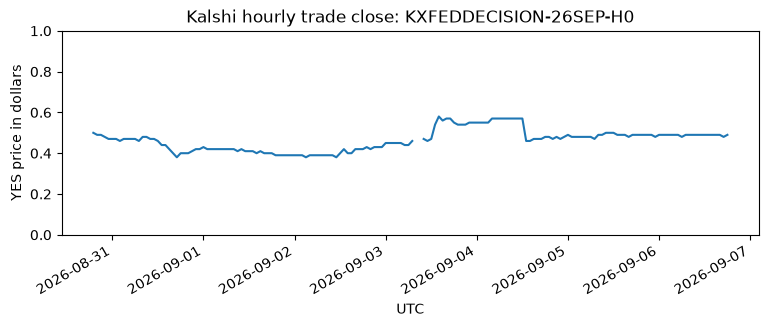

In [16]:
kalshi_candles = get_json(
    KALSHI, f"/series/{quote(series_ticker, safe='')}/markets/{quote(kalshi_ticker, safe='')}/candlesticks",
    start_ts=START_TS, end_ts=END_TS, period_interval=60,
)
kalshi_candles_df = pd.json_normalize(kalshi_candles.get("candlesticks", [])).reindex(columns=[
    "end_period_ts", "price.open_dollars", "price.high_dollars", "price.low_dollars",
    "price.close_dollars", "yes_bid.close_dollars", "yes_ask.close_dollars", "volume_fp",
])
kalshi_candles_df["time_utc"] = pd.to_datetime(kalshi_candles_df["end_period_ts"], unit="s", utc=True)
kalshi_candles_df["trade_close"] = pd.to_numeric(kalshi_candles_df["price.close_dollars"], errors="raise")
display(kalshi_candles_df.head())
if kalshi_candles_df["trade_close"].notna().any():
    ax = kalshi_candles_df.plot(x="time_utc", y="trade_close", figsize=(9, 3), legend=False,
                                title=f"Kalshi hourly trade close: {kalshi_ticker}")
    ax.set(xlabel="UTC", ylabel="YES price in dollars", ylim=(0, 1))
    plt.show()
else:
    print("No trade-close values in this window; inspect quote candles or choose another market.")

### 16. Kalshi: discover the historical boundary

Older data moves to a separate tier. Query `/historical/cutoff` each time; never hardcode an age.
The market/candle boundary depends on the **market's settlement time**, not each candle's timestamp.
An old candle for a still-open market belongs on the live candle route. Trades have their own
creation-time cutoff. Backfills spanning that cutoff must query both trade routes and deduplicate
by `trade_id`. Events/series stay on their regular endpoints, but nested events can omit archived markets.
[Historical data guide](https://docs.kalshi.com/getting_started/historical_data).

In [17]:
kalshi_cutoff = get_json(KALSHI, "/historical/cutoff")
display(pd.DataFrame(kalshi_cutoff.items(), columns=["boundary", "cutoff_utc"]))
kalshi_archive_page = get_json(KALSHI, "/historical/markets", series_ticker=series_ticker, limit=20)
kalshi_archived_markets = kalshi_archive_page["markets"]
_ = preview(kalshi_archived_markets, ["ticker", "title", "result", "close_time", "settlement_ts"])
print("More archived markets available:", bool(kalshi_archive_page.get("cursor")))

,boundary,cutoff_utc
0,market_positions_last_updated_ts,2026-07-08T00:00:00Z
1,market_settled_ts,2026-07-08T00:00:00Z
2,orders_updated_ts,2026-07-08T00:00:00Z
3,trades_created_ts,2026-07-08T00:00:00Z


,ticker,title,result,close_time,settlement_ts
0,KXFEDDECISION-26JUN-H26,Will the Federal Reserve Hike rates by >25bps ...,no,2026-06-17T17:59:00Z,2026-06-17T18:07:43.507539Z
1,KXFEDDECISION-26JUN-H25,Will the Federal Reserve Hike rates by 25bps a...,no,2026-06-17T17:59:00Z,2026-06-17T18:07:43.507539Z
2,KXFEDDECISION-26JUN-H0,Will the Federal Reserve Hike rates by 0bps at...,yes,2026-06-17T17:59:00Z,2026-06-17T18:07:43.507539Z
3,KXFEDDECISION-26JUN-C26,Will the Federal Reserve Cut rates by >25bps a...,no,2026-06-17T17:59:00Z,2026-06-17T18:07:43.507539Z
4,KXFEDDECISION-26JUN-C25,Will the Federal Reserve Cut rates by 25bps at...,no,2026-06-17T17:59:00Z,2026-06-17T18:07:43.507539Z


More archived markets available: True


### 17. Kalshi: fetch archived trades and candles

Choose an archived market from the preceding response, then request its final week before close.
The archived candle response currently uses `price.close`, `volume`, and `open_interest`;
live candles use `price.close_dollars`, `volume_fp`, and `open_interest_fp`. Here, archived `price.close`
is already a **dollar string**, so it needs no cents conversion. Keep raw responses so this
difference remains auditable. [Archived candles](https://docs.kalshi.com/api-reference/historical/get-historical-market-candlesticks).

In [18]:
kalshi_historical_candles = {}
kalshi_historical_trades = {}
kalshi_historical_df = pd.DataFrame()
if kalshi_archived_markets:
    archived = max(kalshi_archived_markets, key=lambda m: Decimal(m.get("volume_fp") or "0"))
    archived_ticker = archived["ticker"]
    archived_end = int(pd.Timestamp(archived["close_time"]).timestamp())
    archived_start = archived_end - 7 * 24 * 60 * 60
    kalshi_historical_candles = get_json(
        KALSHI, f"/historical/markets/{quote(archived_ticker, safe='')}/candlesticks",
        start_ts=archived_start, end_ts=archived_end, period_interval=60,
    )
    kalshi_historical_trades = get_json(KALSHI, "/historical/trades", ticker=archived_ticker,
                                       min_ts=archived_start, max_ts=archived_end, limit=5)
    kalshi_historical_df = pd.json_normalize(kalshi_historical_candles.get("candlesticks", [])).reindex(
        columns=["end_period_ts", "price.close", "yes_bid.close", "yes_ask.close", "volume"])
    kalshi_historical_df["time_utc"] = pd.to_datetime(kalshi_historical_df["end_period_ts"], unit="s", utc=True)
    kalshi_historical_df["trade_close"] = pd.to_numeric(kalshi_historical_df["price.close"], errors="raise")
    print("Archived market:", archived_ticker)
    display(kalshi_historical_df.head())
    print("Archived trades in sample:", len(kalshi_historical_trades.get("trades", [])))
else:
    print("No archived markets in this series sample; choose another series to try this example.")

Archived market: KXFEDDECISION-26JAN-C25


,end_period_ts,price.close,yes_bid.close,yes_ask.close,volume,time_utc,trade_close
0,1769022000,0.0300,0.0200,0.0300,11571.00,2026-01-21 19:00:00+00:00,0.03
1,1769025600,0.0300,0.0200,0.0300,24962.00,2026-01-21 20:00:00+00:00,0.03
2,1769029200,0.0300,0.0200,0.0300,35059.00,2026-01-21 21:00:00+00:00,0.03
3,1769032800,0.0300,0.0200,0.0300,65337.00,2026-01-21 22:00:00+00:00,0.03
4,1769036400,0.0300,0.0200,0.0300,20523.00,2026-01-21 23:00:00+00:00,0.03


Archived trades in sample: 5


### 18. Optional: your private account data

Keep the switches in Setup off to run the entire public tutorial without credentials.
To try account reads, set the appropriate variables in your environment **before starting Jupyter**,
then enable only the platform you want. Do not paste keys into notebook source or outputs.
These examples use existing credentials; they do not create keys or require account funding.

| Platform | Environment variables | What they mean |
|---|---|---|
| Polymarket | `POLYMARKET_ADDRESS`, `POLYMARKET_API_KEY`, `POLYMARKET_API_SECRET`, `POLYMARKET_API_PASSPHRASE` | Signer address and existing CLOB L2 credentials; the API secret is not a wallet private key |
| Kalshi | `KALSHI_API_KEY_ID`, `KALSHI_PRIVATE_KEY_PATH` | Existing API key ID and path to its RSA private PEM file |

Polymarket L2 signs a Unix-seconds timestamp + HTTP method + endpoint path using HMAC-SHA256.
Kalshi signs a Unix-milliseconds timestamp + method + full path using RSA-PSS/SHA256.
Exclude the query string in both GET examples. Production and demo Kalshi credentials differ.
Private results are held in variables; only row counts are displayed and they are not included
in the public export. Clear any private outputs you add yourself before sharing the notebook.

Sources: [Polymarket API authentication](https://docs.polymarket.com/getting-started/api),
[Kalshi authenticated quickstart](https://docs.kalshi.com/getting_started/quick_start_authenticated_requests).

In [19]:
def poly_private_get(path, **params):
    timestamp = str(int(time.time()))
    secret = base64.urlsafe_b64decode(os.environ["POLYMARKET_API_SECRET"])
    message = (timestamp + "GET" + path).encode()
    signature = base64.urlsafe_b64encode(hmac.new(secret, message, hashlib.sha256).digest()).decode()
    headers = {
        "POLY_ADDRESS": os.environ["POLYMARKET_ADDRESS"],
        "POLY_API_KEY": os.environ["POLYMARKET_API_KEY"],
        "POLY_PASSPHRASE": os.environ["POLYMARKET_API_PASSPHRASE"],
        "POLY_TIMESTAMP": timestamp, "POLY_SIGNATURE": signature,
    }
    response = requests.get(CLOB + path, params=params, headers=headers, timeout=(10, 30))
    response.raise_for_status()
    return response.json()

poly_own_orders = poly_own_trades = None
if RUN_POLY_PRIVATE:
    poly_own_orders = poly_private_get("/data/orders")
    poly_own_trades = poly_private_get("/data/trades")
    print("Own orders:", len(poly_own_orders.get("data", [])),
          "| Own trades:", len(poly_own_trades.get("data", [])))
else:
    print("Skipped private Polymarket reads; RUN_POLY_PRIVATE is False.")

Skipped private Polymarket reads; RUN_POLY_PRIVATE is False.


Kalshi's signing path includes `/trade-api/v2` for REST and `/trade-api/ws/v2` for the WebSocket
handshake. Its account positions contain `market_positions` and `event_positions`; fills are
your own executions. Responses with cursors are only first-page samples here. The balance
response can include `balance_dollars`; legacy `balance` and `portfolio_value` are in cents.
[Portfolio balance reference](https://docs.kalshi.com/api-reference/portfolio/get-balance).

In [20]:
def kalshi_headers(url):
    from cryptography.hazmat.primitives import hashes, serialization
    from cryptography.hazmat.primitives.asymmetric import padding

    private_key = serialization.load_pem_private_key(
        Path(os.environ["KALSHI_PRIVATE_KEY_PATH"]).read_bytes(), password=None)
    timestamp = str(int(time.time() * 1000))
    message = (timestamp + "GET" + urlsplit(url).path).encode()
    signature = private_key.sign(message,
        padding.PSS(mgf=padding.MGF1(hashes.SHA256()), salt_length=padding.PSS.DIGEST_LENGTH),
        hashes.SHA256())
    return {
        "KALSHI-ACCESS-KEY": os.environ["KALSHI_API_KEY_ID"],
        "KALSHI-ACCESS-TIMESTAMP": timestamp,
        "KALSHI-ACCESS-SIGNATURE": base64.b64encode(signature).decode(),
    }

def kalshi_private_get(path, **params):
    url = KALSHI + path
    response = requests.get(url, params=params, headers=kalshi_headers(url), timeout=(10, 30))
    response.raise_for_status()
    return response.json()

kalshi_account = {}
if RUN_KALSHI_PRIVATE:
    for name in ("balance", "positions", "fills", "orders"):
        params = {} if name == "balance" else {"limit": 5}
        kalshi_account[name] = kalshi_private_get(f"/portfolio/{name}", **params)
    print("Own market positions:", len(kalshi_account["positions"].get("market_positions", [])),
          "| Fills:", len(kalshi_account["fills"].get("fills", [])),
          "| Orders:", len(kalshi_account["orders"].get("orders", [])))
else:
    print("Skipped private Kalshi reads; RUN_KALSHI_PRIVATE is False.")

Skipped private Kalshi reads; RUN_KALSHI_PRIVATE is False.


### 19. Optional: bounded WebSocket captures

REST gives snapshots; WebSockets push updates. Set `RUN_STREAMS=True` in Setup and rerun this
section. Each capture stops after three messages or eight seconds, plus connection/close time.
Use top-level **`await`** in Jupyter; do not call `asyncio.run()` inside its running event loop.
The helper sends application heartbeats where the Polymarket feeds require them and saves raw
message envelopes with receipt timestamps. It does not build a local order book from deltas.

Long-running collectors need reconnect handling, fresh snapshots, sequence-gap detection, and
durable storage. A reconnect cannot recover messages missed while disconnected.

In [21]:
async def capture_messages(url, subscription, *, headers=None, seconds=8, max_messages=3,
                           heartbeat_seconds=None):
    from websockets.asyncio.client import connect

    async def heartbeat(socket):
        while True:
            await asyncio.sleep(heartbeat_seconds)
            await socket.send("PING")

    messages = []
    async with connect(url, additional_headers=headers, open_timeout=10, close_timeout=2,
                       max_size=4 * 1024 * 1024) as socket:
        await socket.send(json.dumps(subscription))
        task = asyncio.create_task(heartbeat(socket)) if heartbeat_seconds else None
        deadline = asyncio.get_running_loop().time() + seconds
        try:
            while len(messages) < max_messages:
                remaining = deadline - asyncio.get_running_loop().time()
                if remaining <= 0:
                    break
                try:
                    raw = await asyncio.wait_for(socket.recv(), timeout=remaining)
                except asyncio.TimeoutError:
                    break
                if raw in ("PONG", "PING", ""):
                    continue
                messages.append({"received_at_utc": datetime.now(timezone.utc).isoformat(),
                                 "message": json.loads(raw)})
        finally:
            if task:
                task.cancel()
                await asyncio.gather(task, return_exceptions=True)
    return messages

**Polymarket market stream:** subscribe by outcome token ID. Raw event types include `book`,
`price_change`, `last_trade_price`, and lifecycle updates. Heartbeat: text `PING` every 10 seconds.
**RTDS:** a separate contextual feed; the example subscribes to BTC/USDT underlying prices, not
prediction-market contract prices. Heartbeat: text `PING` every 5 seconds.
[Official real-time docs](https://docs.polymarket.com/market-data/realtime-data).

In [22]:
poly_stream = rtds_stream = []
if RUN_STREAMS:
    poly_stream = await capture_messages(
        "wss://ws-subscriptions-clob.polymarket.com/ws/market",
        {"assets_ids": [token_id], "type": "market", "initial_dump": True,
         "custom_feature_enabled": True}, heartbeat_seconds=10,
    )
    rtds_stream = await capture_messages(
        "wss://ws-live-data.polymarket.com",
        {"action": "subscribe", "subscriptions": [
            {"topic": "crypto_prices", "type": "update", "filters": "btcusdt"}]},
        heartbeat_seconds=5,
    )
    print("Market stream envelopes:", len(poly_stream), "| RTDS envelopes:", len(rtds_stream))
    # Inspect poly_stream[0] or rtds_stream[0] locally for a complete raw envelope.
    print(json.dumps(poly_stream[:1], indent=2)[:1000])
else:
    print("Skipped public streams; RUN_STREAMS is False.")

Skipped public streams; RUN_STREAMS is False.


**Kalshi stream:** authentication is required even for public ticker/trade/book channels.
The sample subscribes to ticker updates. To explore the raw order book protocol, change
`channels` to `["orderbook_delta"]` and inspect snapshot, delta, and sequence fields.
[WebSocket quickstart](https://docs.kalshi.com/getting_started/quick_start_websockets).

In [23]:
kalshi_stream = []
if RUN_STREAMS and RUN_KALSHI_PRIVATE:
    kalshi_ws_url = "wss://external-api-ws.kalshi.com/trade-api/ws/v2"
    kalshi_stream = await capture_messages(
        kalshi_ws_url,
        {"id": 1, "cmd": "subscribe", "params": {
            "channels": ["ticker"], "market_tickers": [kalshi_ticker]}},
        headers=kalshi_headers(kalshi_ws_url),
    )
    print("Kalshi stream envelopes:", len(kalshi_stream))
else:
    print("Skipped Kalshi stream; enable RUN_STREAMS and RUN_KALSHI_PRIVATE with credentials.")

Skipped Kalshi stream; enable RUN_STREAMS and RUN_KALSHI_PRIVATE with credentials.


### 20. One more Polymarket API: Bridge asset metadata

The Bridge API exposes supported assets and chains, which is useful for funding metadata.
This call only reads the catalog. It does not generate an address or initiate a transfer.
[Bridge schema](https://docs.polymarket.com/api-spec/bridge-openapi.yaml).

In [24]:
bridge_assets = get_json("https://bridge.polymarket.com", "/supported-assets")
_ = preview(bridge_assets.get("supportedAssets", []),
            ["chainId", "chainName", "token.name", "token.symbol", "minCheckoutUsd"])

,chainId,chainName,token.name,token.symbol,minCheckoutUsd
0,1,Ethereum,TrueUSD,TUSD,5
1,1,Ethereum,DOG,DOG,5
2,1,Ethereum,Basic Attention Token,BAT,5
3,1,Ethereum,1INCH,1INCH,5
4,1,Ethereum,Worldcoin,WLD,5


## Checks

Check identifiers, units, and observed row counts before exporting. Empty samples are not proof
that a market never traded. These assertions check shapes and price ranges, not historical
completeness or equivalence between the selected Polymarket and Kalshi markets.

In [25]:
assert str(poly_book["asset_id"]) == token_id
assert str(poly_book["market"]).lower() == condition_id.lower()
assert kalshi_detail["ticker"] == kalshi_ticker
assert poly_history_df["price"].dropna().between(0, 1).all()
assert kalshi_candles_df["trade_close"].dropna().between(0, 1).all()
assert all(Decimal("0") <= price <= Decimal("1") for price in kalshi_book_df["price"])

coverage = pd.DataFrame([
    ("Gamma discovery events", len(poly_events)),
    ("CLOB sampled prices", len(poly_history_df)),
    ("Polymarket trade sample", len(poly_trades)),
    ("Kalshi current candles", len(kalshi_candles_df)),
    ("Kalshi trade sample", len(kalshi_trades)),
    ("Kalshi archived candles", len(kalshi_historical_df)),
], columns=["dataset", "rows"])
display(coverage)
print("Successful public HTTP responses:", len(public_responses))

,dataset,rows
0,Gamma discovery events,10
1,CLOB sampled prices,25
2,Polymarket trade sample,20
3,Kalshi current candles,167
4,Kalshi trade sample,20
5,Kalshi archived candles,168


Successful public HTTP responses: 44


### Save tables and raw responses

Set `EXPORT_FILES=True` in Setup, or set it in this cell before running. A timestamped folder is
created relative to the notebook's working directory. CSVs hold convenient flat tables;
JSONL retains the original public responses, request parameters, and retrieval times. Optional
public stream envelopes are included separately. Private account results are never included.

In [26]:
if EXPORT_FILES:
    output_dir = Path("api_tutorial_output") / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
    output_dir.mkdir(parents=True, exist_ok=False)
    tables = {
        "polymarket_events": poly_events_df, "polymarket_book": poly_book_df,
        "polymarket_prices": poly_history_df, "polymarket_trades": poly_trades_df,
        "kalshi_series": kalshi_series_df, "kalshi_book": kalshi_book_df,
        "kalshi_candles": kalshi_candles_df, "kalshi_trades": kalshi_trades_df,
        "kalshi_archived_candles": kalshi_historical_df,
    }
    for name, frame in tables.items():
        frame.to_csv(output_dir / f"{name}.csv", index=False)
    with (output_dir / "public_responses.jsonl").open("w", encoding="utf-8") as file:
        for record in public_responses:
            file.write(json.dumps(record, ensure_ascii=False) + "\n")
    (output_dir / "public_streams.json").write_text(
        json.dumps({"polymarket_market": poly_stream, "rtds": rtds_stream}, ensure_ascii=False), encoding="utf-8")
    (output_dir / "manifest.json").write_text(json.dumps({
        "run_started_at_utc": RUN_AT.isoformat(), "history_start_ts": START_TS, "history_end_ts": END_TS,
        "polymarket_condition_id": condition_id, "polymarket_token_id": token_id,
        "kalshi_market_ticker": kalshi_ticker, "kalshi_series_ticker": series_ticker,
        "public_http_responses": len(public_responses), "bounded_sample": True,
    }, indent=2), encoding="utf-8")
    print("Saved to:", output_dir.resolve())
else:
    print("Nothing written. Set EXPORT_FILES=True to save the public extraction.")

Nothing written. Set EXPORT_FILES=True to save the public extraction.


## Next steps

Try changing `SEARCH_TEXT`, selecting another discovered event, or using a public wallet of your
choice. Increase page caps deliberately, preserve continuation cursors, and split long history
windows into bounded chunks. Public Data API trades/activity use `limit`/`offset`, with endpoint
specific caps; they are not unlimited bulk archives. Deduplicate carefully when overlapping
windows or re-reading a moving catalog. Keep UTC timestamps, raw IDs, units, and resolution rules.

The two plotted markets are selected independently. Their prices and volume units should not be
compared as if they described the same contract. Sampled token history and OHLC candles also
have different definitions. To study historical depth, start capturing live books and updates.

More read surfaces, using the same HTTP patterns:

| Surface | Examples / official reference |
|---|---|
| Gamma reference metadata | `/series`, `/sports`, `/teams`, public profiles and related tags — [Gamma schema](https://docs.polymarket.com/api-spec/gamma-openapi.yaml) |
| CLOB condition metadata and batching | `/clob-markets/{condition_id}`, `/markets-by-token/{token_id}`, `/prices`, `/midpoints`, `/spreads`, `/batch-prices-history` — [CLOB schema](https://docs.polymarket.com/api-spec/clob-openapi.yaml) |
| Polymarket account export | `/v1/accounting/snapshot?user=...` returns a ZIP of CSVs, **not JSON**; use `response.content` — [Data schema](https://docs.polymarket.com/api-spec/data-openapi.yaml) |
| Polymarket on-chain analytics / subgraphs | Provider-specific GraphQL, indexed fills and on-chain positions — [Current data resources](https://docs.polymarket.com/resources/blockchain-data). Verify the provider endpoint and schema; older hosted subgraphs may be deprecated or stale. |
| Polymarket related services | Relayer transaction status, Combos market catalog, separate Perps APIs — [API index](https://docs.polymarket.com/llms.txt). These have distinct identifiers and access requirements. |
| Kalshi batch/event candles and books | `/markets/candlesticks`, `/markets/orderbooks`, `/series/{series}/events/{event}/candlesticks` — [Batch candles](https://docs.kalshi.com/api-reference/market/batch-get-market-candlesticks) |
| Kalshi reference and underlying data | Milestones, structured targets, event live data, forecast percentiles, fees and incentives — [API index](https://docs.kalshi.com/llms.txt) |
| Kalshi archived private records | `/historical/fills`, `/historical/orders`, `/historical/positions` — [History guide](https://docs.kalshi.com/getting_started/historical_data) |

For an unfamiliar route, inspect its official schema for required parameters, field units,
pagination, and access requirements before calling it. The appendix is a map for further
exploration; it is not a claim that every listed route was executed in this notebook.

**Troubleshooting:** a 400 usually points to the ID type, query parameters, or range; a 401 to
credentials/signing; a 403 to access restrictions; and a 429 to a rate limit. Respect `Retry-After`
and reduce the request rate. A 404 can mean the contract is no longer served by that endpoint
or that it belongs in Kalshi's historical tier. Empty lists and missing candle prices are valid
responses; inspect status, time window, and pagination before interpreting them.

**Validation:** the public REST cells were executed from a fresh kernel in a separate directory,
without the workspace package. The market WebSocket returned messages and the CSV/JSON export
passed separate checks. RTDS connected but returned no data within the eight-second capture,
so that feed's data delivery was not verified.
Private-account requests and the authenticated Kalshi stream were not live-tested because no
credentials were supplied. Their examples were checked against the linked official documentation.